# Librerías

In [23]:
import os
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input, Rescaling
from tensorboard.plugins.hparams import api as hp

from sklearn.metrics import classification_report

# Análisis de Datos

El dataset utilizado para este proyecto, fue proporcionado por el *Dr. Ernesto García Amaro*. El cual se puede visualizar en el siguiente link: https://github.com/Manumora117/AI-Master-s-Projects-and-Exercises/tree/main/Analisis%20de%20Algoritmos/Enfermedades%20Respiratorias%20Dataset

**NOTAS DEL CÓDIGO:** 

In [35]:
# @title Lectura de base de datos
def procesamiento_datos(ruta):
    clases = os.listdir(ruta)
    
    # Parámetros de estandarización
    size_image = (256,256) # tamaño que tomarán todas las imágenes
    
    plt.figure(figsize=(10, 5 * len(clases)))
    
    for i, nombre_clase in tqdm(enumerate(clases), desc="Procesando clases"):
        ruta_clase = os.path.join(ruta, nombre_clase)
        if not os.path.isdir(ruta_clase):
            continue
            
        # Obtener la primera imagen de la carpeta
        primera_imagen = os.listdir(ruta_clase)[0]
        ruta_img = os.path.join(ruta_clase, primera_imagen)
        
        # ANTES: Leer imagen original
        img_original = image.load_img(ruta_img)
        
        # DESPUÉS: Leer imagen con estandarización (tamaño y color a escala de grises, por ejemplo)
        # Nota: Si prefieres mantener color, omite color_mode="grayscale"
        img_procesada = image.load_img(ruta_img, target_size=size_image, color_mode="grayscale")
        
        # Graficar Antes
        plt.subplot(len(clases), 2, 2*i + 1)
        plt.imshow(img_original)
        plt.title(f"Original: {nombre_clase}\n{img_original.size}")
        plt.axis('off')
        
        # Graficar Después
        plt.subplot(len(clases), 2, 2*i + 2)
        plt.imshow(img_procesada, cmap='gray')
        plt.title(f"Procesada: {nombre_clase}\n{img_procesada.size}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

    # 2. Crear el dataset estandarizado con image_dataset_from_directory
    print("\nCreando el Dataset estandarizado y particiones Train, Val y Test...")
    # Crear conjunto de entrenamiento de 75%
    train_ds = image_dataset_from_directory(
        ruta, # ruta del directorio
        validation_split=0.25, # Dejamos 25% fuera para Val/Test
        subset="training",     # Tomamos el 75%
        seed=69,
        image_size=size_image, # tamaño de las imágenes
        batch_size=32, # tamaño  de los lotes de datos
        color_mode="grayscale", # Cambia a escala de grises
        label_mode="categorical" # Se define el formato de las etiquetas, se puede cambiar a "binary" o "sparse" según las necesidades
    )
    nombre_clases = train_ds.class_names

    # Crear conjunto temporal de 25%
    temp_ds = image_dataset_from_directory(
        ruta, # ruta del directorio
        validation_split=0.25,
        subset="validation",   # Tomamos el 25% restante
        seed=69,
        image_size=size_image, # tamaño de las imágenes
        batch_size=32, # tamaño  de los lotes de datos
        color_mode="grayscale", # Cambia a escala de grises
        label_mode="categorical" # Se define el formato de las etiquetas, se puede cambiar a "binary" o "sparse" según las necesidades
    )
    # Dividir el 25% temporal en Validación (15%) y Test (10%) ---
    # Calculamos cuántos lotes (batches) hay en total en el 25%
    batches = tf.data.experimental.cardinality(temp_ds)
    # Tomamos el 60% de esos batches para Val (que equivale al 15% del total)
    val_size = int(batches.numpy() * 0.6)
    
    val_ds = temp_ds.take(val_size)
    test_ds = temp_ds.skip(val_size)

    print("\nCalculando pesos para balancear las clases...")
    # Obtenemos las etiquetas reales del dataset de entrenamiento para calcular el balanceo, convirtiendo de One-Hot a enteros (argmax)
    y_train = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_ds], axis=0)
    # Calculamos los pesos (Class Weights) en lugar de hacer Oversampling
    clases_unicas = np.unique(y_train)
    pesos = compute_class_weight('balanced', classes=clases_unicas, y=y_train)
    # Convertimos a diccionario para Keras
    class_weights_dict = {clase: peso for clase, peso in zip(clases_unicas, pesos)}
    
    print("-" * 30)
    print(f"Pesos asignados por clase: {class_weights_dict}")
    print("-" * 30)
    
    # 3. Mostrar la distribución de clases en el dataset
    # Obtener los nombres de las clases
    class_names = train_ds.class_names
    # Obtener todas las rutas de archivos que el dataset reconoció
    file_paths = train_ds.file_paths + temp_ds.file_paths
    # Extraer el nombre de la carpeta (clase) de cada ruta de archivo
    # Usamos os.path.split para obtener el nombre del directorio padre
    labels_in_dataset = [os.path.basename(os.path.dirname(p)) for p in file_paths]
    # Contar las ocurrencias
    counts = Counter(labels_in_dataset)

    print("\nResumen del dataset:")
    print(f"Total de imágenes detectadas: {len(file_paths)}")
    for cl in class_names:
        print(f" - Clase '{cl}': {counts[cl]} imágenes")

    # Optimización de velocidad en lectura (Prefetching)
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, test_ds, class_weights_dict, nombre_clases

"""Ejecutamos el procesamiento de datos, con el fin de visualizar el proceso de estandarización y la distribución de clases en el dataset. Se recomienda ejecutar esta celda antes de entrenar el modelo para asegurarse de que los datos se han procesado correctamente.
Y con esto, logramos identificar el estado actual de nuestros datos, lo que nos permitirá tomar decisiones informadas sobre cómo abordar el entrenamiento del modelo y qué técnicas de preprocesamiento adicionales podrían ser necesarias.

NOTA: la función se puede comentar o descomentar según sea necesario, ya que el proceso de estandarización puede ser costoso en términos de tiempo, especialmente si el dataset es grande. Se recomienda ejecutar esta función una vez para verificar los datos y luego comentarlo para acelerar el proceso de entrenamiento."""
#train_ds, val_ds, test_ds, class_weights = procesamiento_datos(r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\Dataset")

'Ejecutamos el procesamiento de datos, con el fin de visualizar el proceso de estandarización y la distribución de clases en el dataset. Se recomienda ejecutar esta celda antes de entrenar el modelo para asegurarse de que los datos se han procesado correctamente.\nY con esto, logramos identificar el estado actual de nuestros datos, lo que nos permitirá tomar decisiones informadas sobre cómo abordar el entrenamiento del modelo y qué técnicas de preprocesamiento adicionales podrían ser necesarias.\n\nNOTA: la función se puede comentar o descomentar según sea necesario, ya que el proceso de estandarización puede ser costoso en términos de tiempo, especialmente si el dataset es grande. Se recomienda ejecutar esta función una vez para verificar los datos y luego comentarlo para acelerar el proceso de entrenamiento.'

# Data Augmentation

**NOTAS DEL CÓDIGO:** 
Se ejecuta un data augmentation debido a que el dataset cuenta con un desbalance de clases o pocas imágenes por categoría. Esto ayuda a que el modelo sea más robusto y no sufra de sobreajuste (overfitting). Para este caso, la mejor forma de implementarlo es ejecutando dentro del sequential del modelo, pero antes de realizar el reescalado de los píxeles. Para esto, primero se ejecuta el data augmenmtation con un *Sequential* y despues se integra dentro de la arquitectura del modelo CNN.
- En la línea de código *tf.keras.layers.RandomBrightness(0.05)* se asigna ±0.05, debido a que las imágenes son radiografías médicas.

In [3]:
def data_augmentation():
    # Este bloque creará variaciones aleatorias de las imágenes originales durante el entrenamiento. En validación y test, se desactiva solo.
    data_augmentation = tf.keras.models.Sequential([
    # Rotaciones aleatorias de hasta ±10% (aprox ±36 grados)
    tf.keras.layers.RandomRotation(0.1),
    
    # Zoom aleatorio de hasta ±10% (zoom in/out)
    tf.keras.layers.RandomZoom(0.1),
    
    # Giros horizontales aleatorios (muy útil en radiografías si no altera el diagnóstico)
    #tf.keras.layers.RandomFlip("horizontal"), # Descomentarlo si el orden de izquierda a derecha no afecta la clasificación (ej. no es un pulmón izquierdo/derecho específico)
    
    # Ligeros cambios en el brillo (ayuda con diferentes exposiciones)
    tf.keras.layers.RandomBrightness(0.05)
], name="capa_aumento_datos")
    
    return data_augmentation



# Modelo CNN

**NOTAS DEL CÓDIGO:** 
En la arquitectura del modelo, primero se decidió asignar una capa principal la cual va a recibir la imagen cruda (256,256) en su escala de grises, es decir; es nuestra capa de entrada. 

Segundo, se decidió incluir dentro de la arquitectura el data augmentation con el fin de reducir el coste de computo. En keras, el usar su propio data augmentation utilizando *Sequential* e incluyendolo dentro de la arquitectura del modelo, se logra evitar que las imágenes se tengan que duplicar en el disco ya que keras lo impide; además de que cada vez que el modelo pide un lote (batch) de entrenamiento, Keras toma las imágenes originales, les aplica rotaciones/zooms aleatorios y se las pasa al modelo. Así, el modelo nunca ve exactamente la misma imagen dos veces.

Otra razon es que se obtiene un manejo automático, debido a que estas capas de aumento se desactivan automáticamente cuando se corre *modelo.evaluate()* o *modelo.predict()*. 

Tercero, se decidió agregar un reescalado en las imágenes con el fin de normalizar los píxeles, es decir; pasar de tener píxeles de $[0, 255]$ a mejor tener valores de $[0, 1]$. La razón de esto es debido a que las redes neuronales sufren si los valores de entrada son muy grandes (255). Al normalizar a un rango de $[0, 1]$, los gradientes son más estables y el entrenamiento es mucho más rápido. La razón por la que el reescalado tambien se agregó dentro de la arquitectura del modelo, es debido a que *TensorFlow* puede ejecutar la operación de reescalado de forma mucho más eficiente dentro del grafo de cómputo de la tarjeta de video. Además, el reescalado se coloco despues del *Data Augmentation* debido a que si se aplica capas de brillo o contraste a las imágenes, se logra mantener estos valores finales de los píxeles y poderlos mantener en unrangfo de $[0, 1]$.

In [ ]:
# @title Arquitectura

def modelo_cnn(data_augmentation, hparams):
    # Extraemos los valores de los objetos HParam de forma segura, con esto se busca si la llave es el objeto HP_NEURONAS o el string 'neuronas_densas'
    n_densas = 0
    drop_rate = 0.0
    
    for k, v in hparams.items():
        if hasattr(k, 'name'):
            if k.name == 'neuronas_densas': n_densas = v
            if k.name == 'dropout': drop_rate = v
        else:
            if k == 'neuronas_densas': n_densas = v
            if k == 'dropout': drop_rate = v
    modelo = Sequential([
        # PRIMERA CAPA: Recibe la imagen cruda (256, 256, 1) y define el shape
        # Nota: El shape debe ir en la primera capa absoluta del modelo Sequential.
        Input(shape=(256,256,1)),

        # DATA AUGMENTATION: Crea variaciones sobre la marcha (solo en entrenamiento)
        data_augmentation,
        
        # REESCALADO: Normaliza de 0-255 a 0-1
        Rescaling(1./255),

        # CAPAS CONVULOCIONALES
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        # CAPAS DENSAS
        Flatten(),
        Dense(n_densas, activation='relu'),
        Dropout(drop_rate), # Ayuda al sobreajuste

        # CAPA DE SALIDA
        Dense(3, activation='softmax') # Se usa softmax para clasificación multiclase
    ])

    return modelo

## **NOTAS:** 

**Modificaciones:**
1. Se corrio el primer grid search a 20 epocas. La corrida duró aproximadamente 7 horas, se corrió a las 07:40 am y terminó 14:20 pm.
2. Ahora la segunda corrida será nuevamente de 20 epochs, quitando en el número de neuronas densas *64* y agregando (*128, 256, 512, 1024*)

In [22]:
# @title Compilación y entrenamiento del modelo
def compilar_entrenar_modelo(hparams, train_ds, val_ds, class_weights, run_dir, data_augmentation):
    modelo = modelo_cnn(data_augmentation, hparams)
    
    # Extraemos el nombre del optimizador del diccionario de hparams
    # Manejamos tanto si es objeto HParam como si es string
    opt_name = ""
    for k, v in hparams.items():
        if (hasattr(k, 'name') and k.name == 'optimizer') or k == 'optimizer':
            opt_name = v
            break
    
    # Configuramos el optimizador con la tasa de aprendizaje deseada
    if opt_name.lower() == 'adam':
        optimizador = tf.keras.optimizers.Adam(learning_rate=0.001)
    elif opt_name.lower() == 'sgd':
        optimizador = tf.keras.optimizers.SGD(learning_rate=0.001)
    else:
        optimizador = opt_name # Deja que Keras use el default si no es adam/sgd
    
    modelo.compile(
        optimizer=optimizador, # El optimizador (adam, sgd, etc)
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks para guardar los resultados en TensorBoard
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=run_dir, histogram_freq=1)
    hparams_callback = hp.KerasCallback(run_dir, hparams)

    history = modelo.fit(train_ds, # Entrenamos con el dataset de entrenamiento (el cual ya incluye las variables X, y)
                         validation_data=val_ds, 
                         epochs=20, # Primer corrida fue de 20 épocas, 
                         class_weight=class_weights, # Usamos los pesos para balancear las clases durante el entrenamiento
                         callbacks=[tensorboard_callback, hparams_callback],
                         verbose=1 # Muestra una barra de progreso durante el entrenamiento
                         )
    
    # Obtenemos el accuracy final
    _, accuracy = modelo.evaluate(val_ds)
    # Retornamos el mejor accuracy de validación y el modelo
    #accuracy = max(history.history['val_accuracy'])
    return accuracy, modelo

*NOTA DE AVANCE:* Aún no termino al 100% el código, aún me faltan cosas por afinar, puede que le realice cambios al código en un futuro (ya que aún no lo ejecuto y no he medido el accuracy y demás valores). Pero al menos la parte de *Analisis de Datos* y *Data Augmentation* ya estan listas (puede que le realice una modificación, pero si lo llego hacer te aviso). Y en la parte de la arquitectura del modelo aun sigo trabajando en ello, pero al menos ya te dejo uan idea de como va a estar estructurado (posiblemente los cambios que realice sean más de agregar o quitar algunos comandos o hiperparámetros).

In [ ]:
# @title Grid Search y Guardado de resultados en TensorBoard

def ejecutar_grid_search(train_ds, val_ds, class_weights, data_augmentation, hparams_list, directorio_logs):
    HP_NEURONAS, HP_DROPOUT, HP_OPTIMIZER = hparams_list
    sesion = 1
    mejor_accuracy = 0
    mejor_modelo = None

    # DataFrame de resultados de corrida
    df_modelos = pd.DataFrame(columns=['run', 'Modelo', 'Accuracy'])

    # Anidamos los bucles para crear la "Cuadrícula" (Grid)
    for neuronas in HP_NEURONAS.domain.values:
        for dropout_rate in HP_DROPOUT.domain.values:
            for optimizador in HP_OPTIMIZER.domain.values:
                
                # Diccionario del experimento actual
                hparams = {
                    HP_NEURONAS: neuronas,
                    HP_DROPOUT: dropout_rate,
                    HP_OPTIMIZER: optimizador,
                }
                
                nombre_run = f"run-{sesion}_N{neuronas}_D{dropout_rate}_O{optimizador}"
                print(f'\n--- Iniciando Experimento: {nombre_run} ---')
                print({h.name: hparams[h] for h in hparams})
                ruta_run = os.path.join(directorio_logs, nombre_run)
                
                # Entrenamos
                accuracy, modelo = compilar_entrenar_modelo(
                    hparams, train_ds, val_ds, class_weights, ruta_run, data_augmentation)
                
                # Guardar fila en df_modelos
                fila = {'run': nombre_run, 'Modelo': nombre_run, 'Accuracy': accuracy}
                df_modelos = pd.concat([df_modelos, pd.DataFrame([fila])], ignore_index=True)
                
                # Actualizamos el mejor modelo
                if accuracy > mejor_accuracy:
                    mejor_accuracy = accuracy
                    mejor_modelo = modelo
                    
                sesion += 1

    # Guardamos el mejor modelo
    # Nota: .keras es el nuevo estándar oficial.
    mejor_modelo.save(f'mejor_modelo_{nombre_run}.keras')
    print(f"\nEl mejor modelo ha sido guardado con un Accuracy de: {mejor_accuracy}. Y sus parámetros son: {nombre_run}")

    # Guardamos el DataFrame de todas las corridas
    df_modelos.to_csv( r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\resultados_grid_search.csv", index=False)
    # df_modelos.to_parquet("resultados_grid_search.parquet", index=False)  # opcional

    print("\nResumen de resultados guardado en: resultados_grid_search.csv")
    print(df_modelos.head())

    return mejor_modelo, df_modelos

""" Para mostrar los resultados en el Localhost (TensorBoard)
- Si estás usando Jupyter Notebook o Google Colab, puedes abrir TensorBoard directamente en una celda agregando este código al final:
    # Cargar la extensión de TensorBoard
    %load_ext tensorboard
    # Iniciar TensorBoard leyendo la carpeta que acabamos de crear
    %tensorboard --logdir "<ruta a la carpeta de logs>"

- Si estás usando un entorno local (como VSCode), puedes abrir una terminal y ejecutar el siguiente comando para iniciar TensorBoard:
    tensorboard --logdir="<ruta a la carpeta de logs>"
    Luego, abre tu navegador y ve a http://localhost:6006/ para visualizar los resultados."""

' Para mostrar los resultados en el Localhost (TensorBoard)\n- Si estás usando Jupyter Notebook o Google Colab, puedes abrir TensorBoard directamente en una celda agregando este código al final:\n    # Cargar la extensión de TensorBoard\n    %load_ext tensorboard\n    # Iniciar TensorBoard leyendo la carpeta que acabamos de crear\n    %tensorboard --logdir "<ruta a la carpeta de logs>"\n\n- Si estás usando un entorno local (como VSCode), puedes abrir una terminal y ejecutar el siguiente comando para iniciar TensorBoard:\n    tensorboard --logdir=<ruta a la carpeta de logs>\n    Luego, abre tu navegador y ve a http://localhost:6006/ para visualizar los resultados.'

# Predicción y resultados

In [46]:
def prediccion_resultados(modelo, test_ds,  class_names):
    # REESCALADO: Normaliza de 0-255 a 0-1
    test_ds = test_ds.map(lambda x, y: (Rescaling(1./255)(x), y)) # Aseguramos que el dataset de test también esté normalizado, esto es crucial para obtener predicciones correctas del modelo, ya que fue entrenado con imágenes reescaladas. Si no se reescala el test_ds, las predicciones podrían ser erróneas debido a la discrepancia en la escala de los datos.
    # Obtenemos las etiquetas verdaderas y las predicciones del modelo
    y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_ds], axis=0)
    y_pred_prob = modelo.predict(test_ds)
    y_pred = np.argmax(y_pred_prob, axis=1) # Convertimos las probabilidades a etiquetas de clase (índices)
    probabilidad = np.max(y_pred_prob, axis=1) # Obtenemos la probabilidad de la clase predicha para cada muestra
    print(f"Confianza de la predicción: {round(np.mean(probabilidad) * 100, 2)}%")
    
    # Imprimimos el reporte de clasificación
    print("\nReporte de Clasificación en el conjunto de Test:")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Ejecución del programa

**ADVERTENCIA:** AL MOMENTO DE QUERER CORRER EL SIGUIENTE CÓDIGO DE ABAJO

Correr el programa si se quiere realizar el grid search, ya que la ejecucción de este Grid Search es de aprox. 36 hrs. Y las características de la computadora donde se corrió el programa son las siguinetes:
- Ryzen 5 8600G
- Gráficos Integrados (Gráficos del propio procesador)
- Memoria RAM 32GB

**NOTA:** al momento de correr el programa, se llegó a ocupar 20GB de RAM y en cada epoch se tardaba aprox. 4-5 minutos

Procesando clases: 0it [00:00, ?it/s]

Procesando clases: 3it [00:01,  2.44it/s]


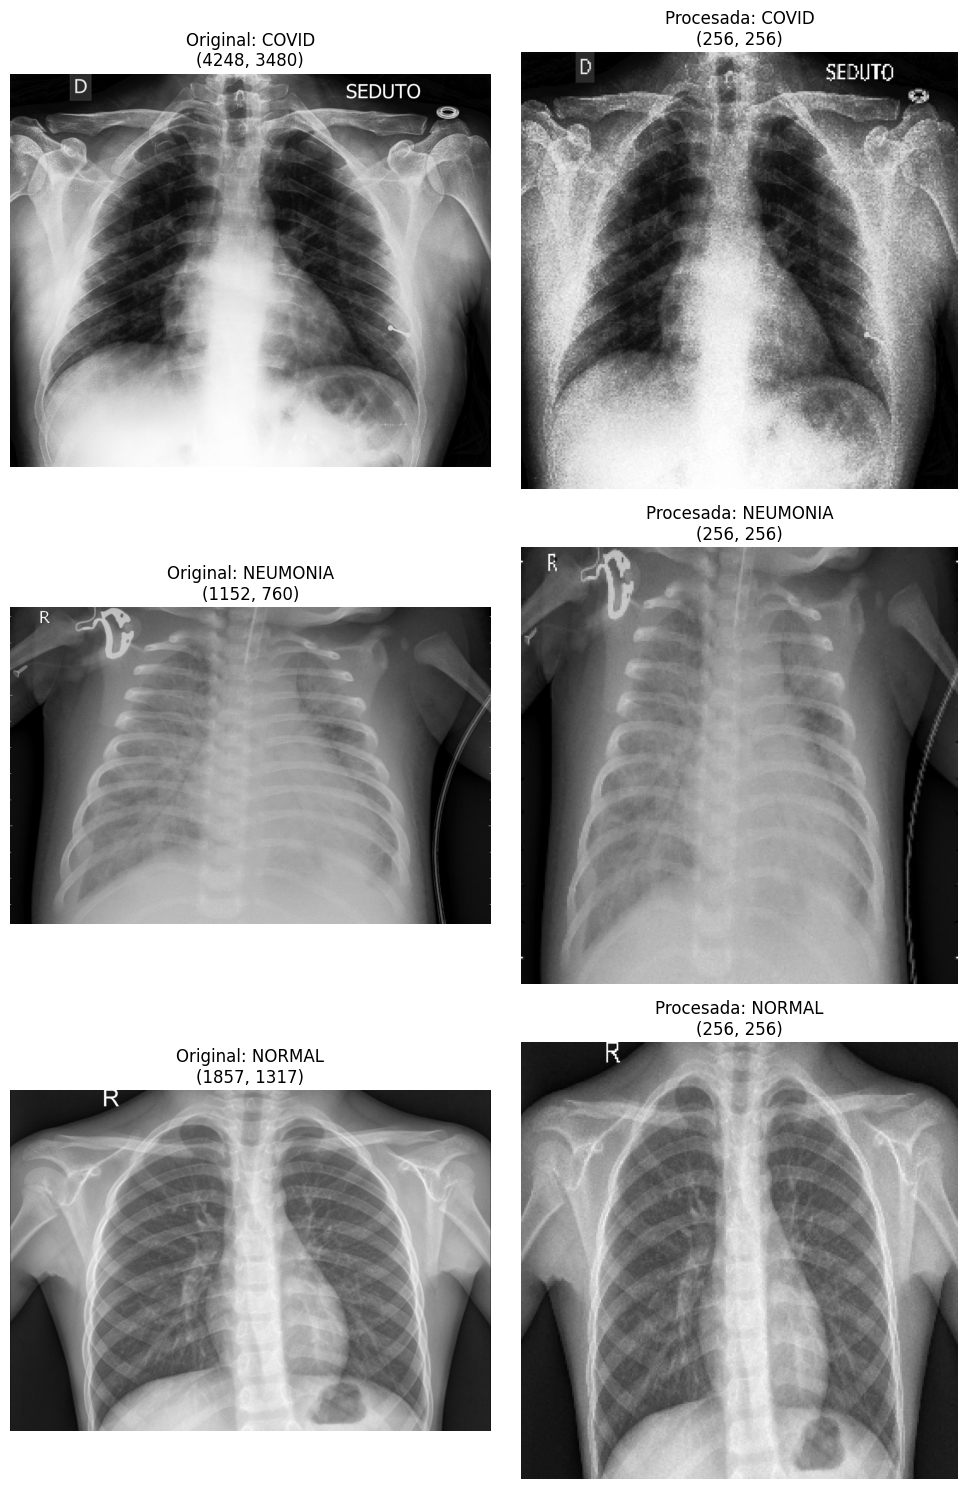


Creando el Dataset estandarizado y particiones Train, Val y Test...
Found 6056 files belonging to 3 classes.
Using 4542 files for training.
Found 6056 files belonging to 3 classes.
Using 1514 files for validation.

Calculando pesos para balancear las clases...
------------------------------
Pesos asignados por clase: {np.int64(0): np.float64(10.093333333333334), np.int64(1): np.float64(0.4710640945861854), np.int64(2): np.float64(1.2852292020373515)}
------------------------------

Resumen del dataset:
Total de imágenes detectadas: 6056
 - Clase 'COVID': 200 imágenes
 - Clase 'NEUMONIA': 4273 imágenes
 - Clase 'NORMAL': 1583 imágenes

--- Iniciando Experimento: run-1_N128_D0.3_Oadam ---
{'neuronas_densas': 128, 'dropout': 0.3, 'optimizer': 'adam'}
Epoch 1/20


g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.6332 - loss: 0.7652 - val_accuracy: 0.8471 - val_loss: 0.3966
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7831 - loss: 0.4784 - val_accuracy: 0.8315 - val_loss: 0.3847
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7992 - loss: 0.4457 - val_accuracy: 0.8192 - val_loss: 0.3999
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8049 - loss: 0.3996 - val_accuracy: 0.8750 - val_loss: 0.3650
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8305 - loss: 0.3629 - val_accuracy: 0.8728 - val_loss: 0.3223
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8382 - loss: 0.3278 - val_accuracy: 0.9196 - val_loss: 0.2041
Epoch 7/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8443 - loss: 0.3304 - val_accuracy: 0.8895 - val_loss: 0.2771
Epoch 8/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8602 - loss: 0.2989 - val_accuracy: 0.910

C:\Users\hidey\AppData\Local\Temp\ipykernel_19756\887256983.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_modelos = pd.concat([df_modelos, pd.DataFrame([fila])], ignore_index=True)


Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.6063 - loss: 1.0933 - val_accuracy: 0.6272 - val_loss: 0.8175
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7561 - loss: 0.5392 - val_accuracy: 0.7031 - val_loss: 0.6416
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8025 - loss: 0.4520 - val_accuracy: 0.8538 - val_loss: 0.3346
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8258 - loss: 0.4244 - val_accuracy: 0.9074 - val_loss: 0.2671
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8531 - loss: 0.3623 - val_accuracy: 0.7143 - val_loss: 0.7107
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8644 - loss: 0.3570 - val_accuracy: 0.9263 - val_loss: 0.1910
Epoch 7/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8692 - loss: 0.3189 - val_accuracy: 0.9286 - val_loss: 0.2171
Epoch 8/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.8800 - loss: 0.2879 - val_accu

TypeError: cannot pickle 'module' object

In [ ]:
def main():
    ruta = r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\Dataset"
    # =================DEFINIR EL GRID SEARCH (Hiperparámetros)=================
    # Probaremos diferentes cantidades de neuronas y porcentajes de Dropout
    HP_NEURONAS = hp.HParam('neuronas_densas', hp.Discrete([128, 256, 512, 1024])) # se quita 64 debido a que no esta dando buenos resultados en las pruebas iniciales, se puede volver a agregar si se desea probar con más opciones
    HP_DROPOUT = hp.HParam('dropout', hp.Discrete([0.3, 0.5, 0.7]))
    HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'rmsprop']))
    list_hparams = [HP_NEURONAS, HP_DROPOUT, HP_OPTIMIZER]

    METRICA_ACCURACY = 'val_accuracy'

    # Carpeta principal donde TensorBoard leerá los datos
    directorio_logs = r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\logs/hparam_tuning" # Cambiar esta ruta según tu estructura de carpetas

    # Configuramos TensorBoard para que sepa qué variables estamos midiendo
    with tf.summary.create_file_writer(directorio_logs).as_default():
        hp.hparams_config(
            hparams=[HP_NEURONAS, HP_DROPOUT, HP_OPTIMIZER],
            metrics=[hp.Metric(METRICA_ACCURACY, display_name='Accuracy')],
        )
    train_ds, val_ds, test_ds, class_weights = procesamiento_datos(ruta)
    data_augmentation_layer = data_augmentation()
    modelo, df_modelos = ejecutar_grid_search(train_ds, val_ds, class_weights, data_augmentation_layer, list_hparams, directorio_logs)
    prediccion_resultados(modelo, test_ds)

    # ordenar de mayor a menor por Accuracy
    df_ord = df_modelos.sort_values('Accuracy', ascending=False)

    # tomar 50% de las filas (los mejores)
    n = int(len(df_ord) * 0.5)
    display(df_ord.head(n))
    

if __name__ == '__main__':
    main()

# Ejecución del modelo Real (Mejor accuracy)

In [14]:
# @title Visualización de resultados en TensorBoard
from tbparse import SummaryReader

# 1. Leer todos los eventos de la carpeta 'log'
reader = SummaryReader(r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\logs\hparam_tuning", extra_columns={'dir_name'})
df = reader.tensors # Extraemos el DataFrame con los datos de TensorBoard

# 2. Filtrar solo los registros correspondientes al accuracy 
df_acc = df[df['tag'] == 'epoch_accuracy'] # (cambia 'accuracy' por 'val_accuracy' si se prefiere la métrica de validación)
display(df_acc)

# 3. Obtener el mejor accuracy para cada modelo (run)
mejores_modelos = df_acc.groupby('dir_name')['value'].max().reset_index()

# 4. Ordenar los resultados de forma ascendente
modelos_ordenados = mejores_modelos.sort_values(by='value', ascending=False)

print(modelos_ordenados)

,step,tag,value,dir_name
100,0,epoch_accuracy,0.617569,run-10_N256_D0.5_Ormsprop/train
101,1,epoch_accuracy,0.779612,run-10_N256_D0.5_Ormsprop/train
102,2,epoch_accuracy,0.824527,run-10_N256_D0.5_Ormsprop/train
103,3,epoch_accuracy,0.848085,run-10_N256_D0.5_Ormsprop/train
104,4,epoch_accuracy,0.857772,run-10_N256_D0.5_Ormsprop/train
...,...,...,...,...
8188,15,epoch_accuracy,0.93192,run-9_N256_D0.5_Oadam/validation
8189,16,epoch_accuracy,0.895089,run-9_N256_D0.5_Oadam/validation
8190,17,epoch_accuracy,0.868304,run-9_N256_D0.5_Oadam/validation
8191,18,epoch_accuracy,0.902902,run-9_N256_D0.5_Oadam/validation


                                 dir_name     value
9    run-14_N512_D0.3_Ormsprop/validation  0.958705
13   run-16_N512_D0.5_Ormsprop/validation  0.957589
45    run-8_N256_D0.3_Ormsprop/validation  0.955357
37    run-4_N128_D0.5_Ormsprop/validation  0.954241
27  run-22_N1024_D0.5_Ormsprop/validation  0.954241
43       run-7_N256_D0.3_Oadam/validation  0.953125
17   run-18_N512_D0.7_Ormsprop/validation  0.953125
31  run-24_N1024_D0.7_Ormsprop/validation  0.953125
47       run-9_N256_D0.5_Oadam/validation  0.952009
33    run-2_N128_D0.3_Ormsprop/validation  0.950893
7       run-13_N512_D0.3_Oadam/validation  0.950893
23  run-20_N1024_D0.3_Ormsprop/validation  0.950893
41    run-6_N128_D0.7_Ormsprop/validation  0.948661
5    run-12_N256_D0.7_Ormsprop/validation  0.947545
1    run-10_N256_D0.5_Ormsprop/validation  0.947545
19     run-19_N1024_D0.3_Oadam/validation  0.946429
21       run-1_N128_D0.3_Oadam/validation  0.945312
11      run-15_N512_D0.5_Oadam/validation  0.944196
25     run-2

De acuerdo a los resultados obtenidos del *Grid Search*, los mejores hiperparámetros obtenidos fueron en la corrida no. 14 con 512 neuronas densas, un dropout de *0.3* y un optimizador de *rmsprop*, arrojando un accuracy de *0.958705*. Aunque se esta tomando en cuenta el accuracy obtenido en la validación.

Procesando clases: 3it [00:00,  6.50it/s]


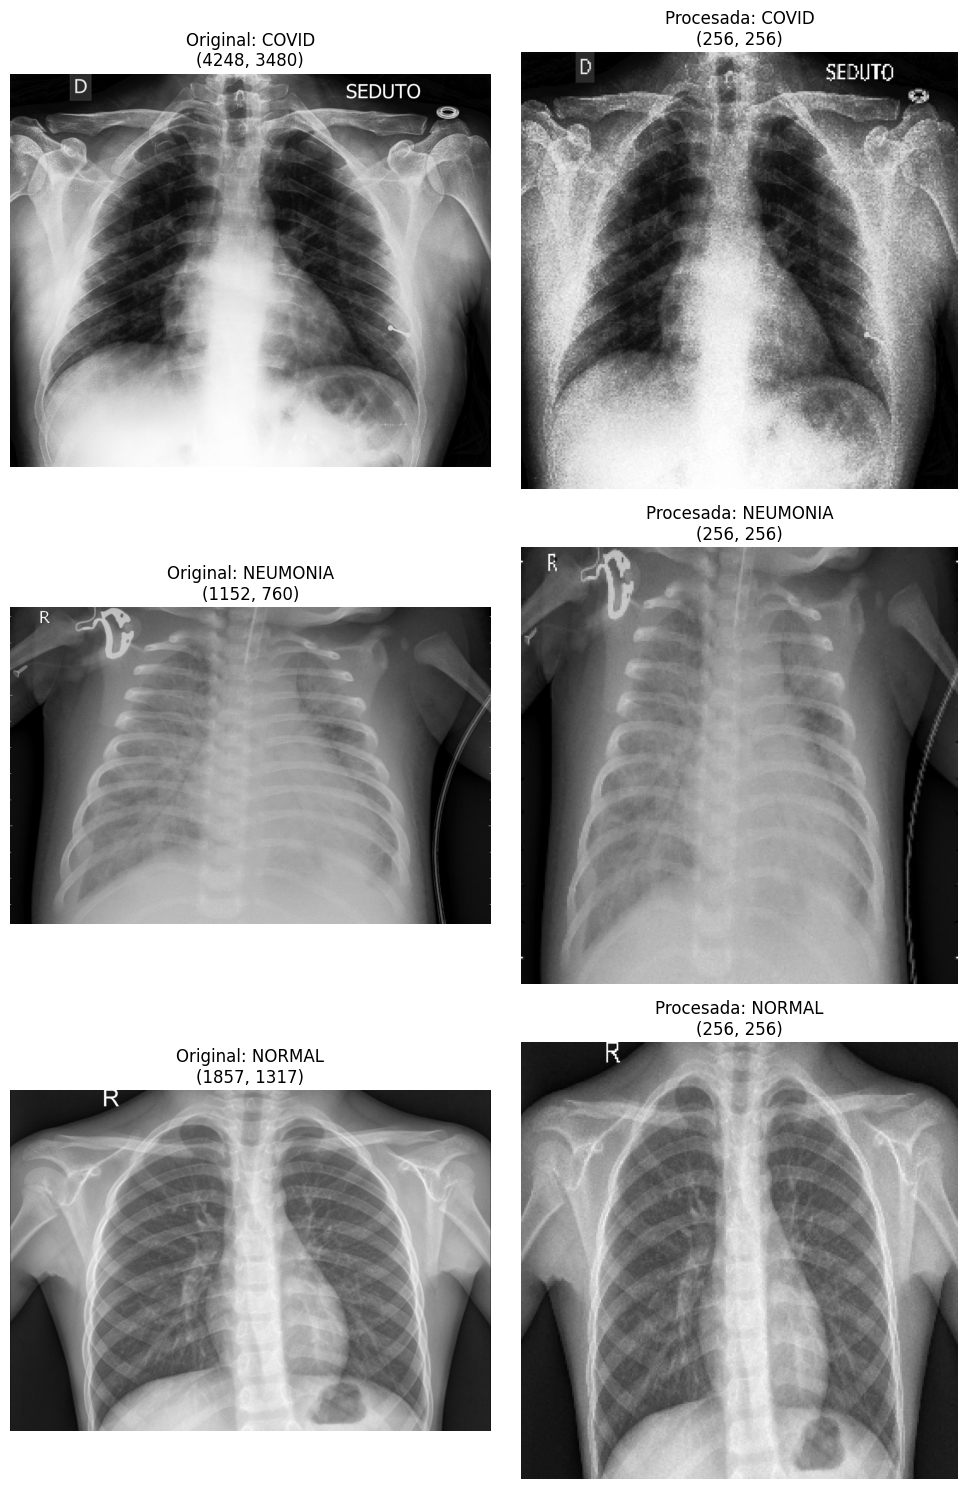


Creando el Dataset estandarizado y particiones Train, Val y Test...
Found 6056 files belonging to 3 classes.
Using 4542 files for training.
Found 6056 files belonging to 3 classes.
Using 1514 files for validation.

Calculando pesos para balancear las clases...
------------------------------
Pesos asignados por clase: {np.int64(0): np.float64(10.093333333333334), np.int64(1): np.float64(0.4710640945861854), np.int64(2): np.float64(1.2852292020373515)}
------------------------------

Resumen del dataset:
Total de imágenes detectadas: 6056
 - Clase 'COVID': 200 imágenes
 - Clase 'NEUMONIA': 4273 imágenes
 - Clase 'NORMAL': 1583 imágenes
Epoch 1/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 103s 647ms/step - accuracy: 0.5947 - loss: 0.9227 - val_accuracy: 0.8214 - val_loss: 0.4225
Epoch 2/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 90s 636ms/step - accuracy: 0.7761 - loss: 0.4901 - val_accuracy: 0.8683 - val_loss: 0.3300
Epoch 3/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 91s 642ms/step - accuracy: 0.8100 - loss: 0.4234 - 

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [43]:
# @title Modelo final con los mejores hiperparámetros encontrados
ruta = r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\Dataset"
directorio_logs = r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\logs_official/hparam_tuning" # Cambiar esta ruta según tu estructura de carpetas
train_ds, val_ds, test_ds, class_weights, nombre_clases = procesamiento_datos(ruta)

modelo = Sequential([
        # PRIMERA CAPA: Recibe la imagen cruda (256, 256, 1) y define el shape
        # Nota: El shape debe ir en la primera capa absoluta del modelo Sequential.
        Input(shape=(256,256,1)), # Input es el estándar moderno en Keras 3

        # DATA AUGMENTATION: Crea variaciones sobre la marcha (solo en entrenamiento)
        data_augmentation(),
        
        # REESCALADO: Normaliza de 0-255 a 0-1
        Rescaling(1./255),

        # CAPAS CONVULOCIONALES
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        # CAPAS DENSAS
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.3), # Ayuda al sobreajuste

        # CAPA DE SALIDA
        Dense(3, activation='softmax') # Se usa softmax para clasificación multiclase
    ])

modelo.compile(
        optimizer='rmsprop',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
# Callbacks para guardar los resultados en TensorBoard
run_dir = os.path.join(directorio_logs, 'ND512_D0.3_Ormsprop')
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=run_dir, histogram_freq=1)

history = modelo.fit(train_ds, # Entrenamos con el dataset de entrenamiento (el cual ya incluye las variables X, y)
                    validation_data=val_ds, 
                    epochs=100, # Primer corrida fue de 100 épocas, 
                    class_weight=class_weights, # Usamos los pesos para balancear las clases durante el entrenamiento
                    callbacks=[tensorboard_callback],
                    verbose=1 # Muestra una barra de progreso durante el entrenamiento
                    )
modelo.save(f'mejor_modelo_final.keras') # Guardamos el modelo final entrenado
    
# Obtenemos el accuracy final
_, accuracy = modelo.evaluate(val_ds)
print(f"\nAccuracy final en validación: {accuracy}")

prediccion_resultados(modelo, test_ds, nombre_clases)

**INFORMACIÓN DE LA EJECUCIÓN DEL MODELO REAL (CON MEJORES HIPERPARÁMETROS):** el modelo tardo en entrenar 151 minutos 22.9 segundos,que eso es aproximadamente unas 2 horas 31 minutos 22.9 segundos (2:31:22:90). Dando una media de tiempo en cada epoch de 91 segundos.
- El coste de computo fue el siguiente:
    - Memoria RAM: Aprox. 20 GB
    - Procesador: 69.6% de su capacidad (contemplando uso de python + VSC)
    - GPU: no se ocupo, ya que el equipo de computo que se utilizo no cuenta con una, solo cuenta con gráficos integrados del propio procesaodr (y esos el programa no los contempla).

**NOTA:** ignorar el erro que aparece arriba, no significa nada malo para el programa. Solo quería demostrar los resultados de prediccion pero tuve un problema con una línea de código. 

Pero los resultados, se pueden visualizar abajo.

Procesando clases: 3it [00:00,  7.31it/s]


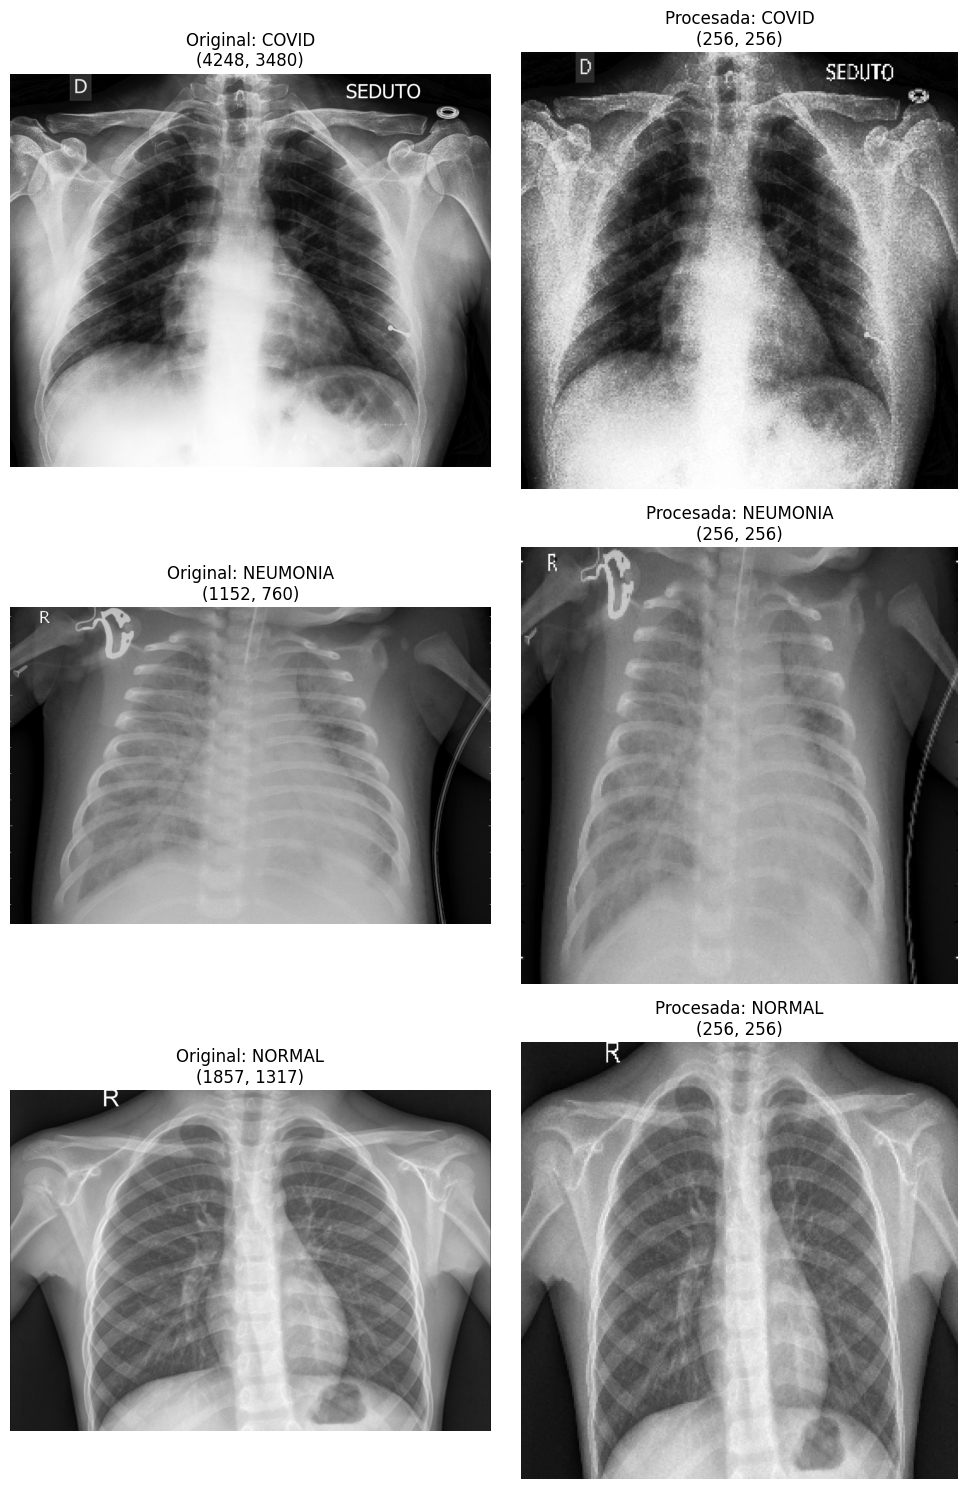


Creando el Dataset estandarizado y particiones Train, Val y Test...
Found 6056 files belonging to 3 classes.
Using 4542 files for training.
Found 6056 files belonging to 3 classes.
Using 1514 files for validation.

Calculando pesos para balancear las clases...
------------------------------
Pesos asignados por clase: {np.int64(0): np.float64(10.093333333333334), np.int64(1): np.float64(0.4710640945861854), np.int64(2): np.float64(1.2852292020373515)}
------------------------------

Resumen del dataset:
Total de imágenes detectadas: 6056
 - Clase 'COVID': 200 imágenes
 - Clase 'NEUMONIA': 4273 imágenes
 - Clase 'NORMAL': 1583 imágenes
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step
Confianza de la predicción: 99.95999908447266%

Reporte de Clasificación en el conjunto de Test:
              precision    recall  f1-score   support

       COVID       0.00      0.00      0.00        21
    NEUMONIA       0.71      1.00      0.83       436
      NORMAL       0.00      0.00      0.00       161

 

g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [47]:
# Ejecutar la predicción con el modelo guardado

ruta = r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\Dataset"
train_ds, val_ds, test_ds, class_weights, nombre_clases = procesamiento_datos(ruta)
# Cargar el modelo
modelo_cargado = tf.keras.models.load_model(r"G:\Mi unidad\CUATRIMESTRES\2\ANALISIS DE ALGORITMOS\Proyecto\mejor_modelo_final.keras")

prediccion_resultados(modelo_cargado, test_ds, nombre_clases)

# Proyecto Final en equipo - Procesamiento de imágenes (*Aprendizaje Supervisado*)